# Graphs & Plots — Standalone

Reads saved CSVs from the 10-seed CV run + the Excel data file.
Generates all 11 figures for the paper. No dependency on previous notebook variables.

In [ ]:
# ============================================================
# 0. Setup
# ============================================================

import os
BASE_DIR = '/content/drive/My Drive/CRISPR Hirsfeld'
RESULTS_DIR = os.path.join(BASE_DIR, 'cv_results_v15')
os.chdir(BASE_DIR)
print('CWD:', os.getcwd())

Mounted at /content/drive
CWD: /content/drive/My Drive/CRISPR Hirsfeld


In [ ]:
# ============================================================
# 1. Imports + load everything from scratch
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import re
import warnings
warnings.filterwarnings('ignore')
from time import time

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, silhouette_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.decomposition import PCA, KernelPCA, SparsePCA, TruncatedSVD, FactorAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from pycm import ConfusionMatrix as PyCM_CM

plt.rcParams['figure.figsize'] = (8, 5)
print('Imports OK')

Imports OK


In [ ]:
# ============================================================
# 2. Load CV results from saved CSVs
# ============================================================
df_summary = pd.read_csv(os.path.join(RESULTS_DIR, 'summary_10seeds.csv'))
df_all = pd.read_csv(os.path.join(RESULTS_DIR, 'all_seed_results.csv'))
df_posthoc = pd.read_csv(os.path.join(RESULTS_DIR, 'posthoc_wilcoxon.csv'))
df_friedman = pd.read_csv(os.path.join(RESULTS_DIR, 'friedman_results.csv'))

print(f'Summary: {len(df_summary)} combos')
print(f'All seeds: {len(df_all)} rows ({df_all["Seed_idx"].nunique()} seeds)')
print(f'Post-hoc: {len(df_posthoc)} pairs, {(df_posthoc["Sig"]!="ns").sum()} significant')
display(df_summary[['Decomposition','Classifier','Accuracy_str','Macro-F1_str','MCC_str','MCEN_str']])

Summary: 15 combos
All seeds: 150 rows (10 seeds)
Post-hoc: 90 pairs, 78 significant


,Decomposition,Classifier,Accuracy_str,Macro-F1_str,MCC_str,MCEN_str
0,Standard PCA,Decision Tree,0.2362±0.0043,0.2181±0.0050,0.1781±0.0047,0.7885±0.0042
1,Standard PCA,Random Forest,0.2912±0.0022,0.2582±0.0028,0.2372±0.0025,0.6986±0.0017
2,Standard PCA,Extra Trees,0.2930±0.0023,0.2544±0.0028,0.2390±0.0026,0.6870±0.0020
3,Kernel PCA (RBF),Decision Tree,0.1938±0.0020,0.1775±0.0020,0.1324±0.0021,0.8183±0.0014
4,Kernel PCA (RBF),Random Forest,0.2664±0.0032,0.2312±0.0038,0.2100±0.0035,0.7125±0.0031
5,Kernel PCA (RBF),Extra Trees,0.2624±0.0024,0.2225±0.0021,0.2058±0.0027,0.7056±0.0027
6,Sparse PCA,Decision Tree,0.3707±0.0051,0.3522±0.0045,0.3228±0.0054,0.6869±0.0042
7,Sparse PCA,Random Forest,0.3560±0.0044,0.3277±0.0045,0.3084±0.0047,0.6521±0.0042
8,Sparse PCA,Extra Trees,0.3584±0.0029,0.3255±0.0041,0.3110±0.0033,0.6429±0.0026
9,Truncated SVD,Decision Tree,0.2347±0.0034,0.2167±0.0039,0.1764±0.0036,0.7895±0.0037


In [ ]:
# ============================================================
# 3. Load + preprocess original data (for scatter plots, chr3, etc.)
# ============================================================
df = pd.read_excel('excel full.xlsx')

def pick(cols, candidates):
    for c in candidates:
        if c in cols: return c
    return None

cols = df.columns.tolist()
CONTIG_COL = pick(cols, ['contig','contg','chrom','chromosome','chr'])
SEQ_COL = pick(cols, ['exp_flanking_sequence','flanking_sequence','flank_seq','sequence','seq'])
COORD_START = pick(cols, ['coord_start','cas_coord_start','start'])
COORD_END = pick(cols, ['coord_end','cas_coord_end','end'])
STRAND_COL = pick(cols, ['strand','Strand'])

TOPK = 15
topk = df[CONTIG_COL].astype(str).value_counts().head(TOPK).index
df_work = df[df[CONTIG_COL].astype(str).isin(topk)].copy()

def gc_content(seq):
    seq = str(seq).upper(); v = [b for b in seq if b in 'ACGT']
    return sum(b in 'GC' for b in v) / len(v) if v else 0.0
def gc_skew(seq):
    seq = str(seq).upper(); g, c = seq.count('G'), seq.count('C')
    return (g - c) / (g + c) if (g + c) else 0.0
def at_skew(seq):
    seq = str(seq).upper(); a, t = seq.count('A'), seq.count('T')
    return (a - t) / (a + t) if (a + t) else 0.0
def shannon_entropy(seq):
    seq = str(seq).upper()
    counts = np.array([seq.count(b) for b in 'ACGT'], dtype=np.float32)
    total = counts.sum()
    if total <= 0: return 0.0
    p = counts / total; p = p[p > 0]
    return float(-(p * np.log2(p)).sum())
def max_homopolymer(seq):
    seq = str(seq).upper(); best = run = 0; prev = None
    for b in seq:
        if b not in 'ACGT': run = 0; prev = None; continue
        run = run + 1 if b == prev else 1; prev = b; best = max(best, run)
    return best

df_work['seq_len'] = df_work[SEQ_COL].astype(str).str.len()
df_work['gc_content'] = df_work[SEQ_COL].apply(gc_content)
df_work['gc_skew'] = df_work[SEQ_COL].apply(gc_skew)
df_work['at_skew'] = df_work[SEQ_COL].apply(at_skew)
df_work['entropy'] = df_work[SEQ_COL].apply(shannon_entropy)
df_work['max_homopolymer'] = df_work[SEQ_COL].apply(max_homopolymer)
if COORD_START and COORD_END:
    df_work[COORD_START] = pd.to_numeric(df_work[COORD_START], errors='coerce')
    df_work[COORD_END] = pd.to_numeric(df_work[COORD_END], errors='coerce')
    df_work['dsb_span'] = (df_work[COORD_END] - df_work[COORD_START]).abs()
    df_work['midpoint'] = (df_work[COORD_END] + df_work[COORD_START]) / 2.0
if STRAND_COL:
    s = df_work[STRAND_COL].astype(str).str.strip().str.lower()
    df_work['strand_num'] = np.where(s.isin(['+','plus','1','forward','fwd']), 1,
                            np.where(s.isin(['-','minus','-1','reverse','rev']), -1, 0))

engineered = ['seq_len','gc_content','gc_skew','at_skew','entropy','max_homopolymer']
engineered += [c for c in ['dsb_span','midpoint','strand_num'] if c in df_work.columns]
coord_raw = [c for c in [COORD_START, COORD_END] if c is not None]
numeric_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()
exclude = {SEQ_COL, CONTIG_COL}
exclude |= {c for c in numeric_cols if re.fullmatch(r'(id|ID|index|row_id|site_id)', str(c))}
pca_cols = list(dict.fromkeys(engineered + coord_raw + numeric_cols))
pca_cols = [c for c in pca_cols if c not in exclude]
X = df_work[pca_cols].copy()
na_frac = X.isna().mean()
drop_cols = na_frac[na_frac > 0.60].index.tolist()
if drop_cols: X = X.drop(columns=drop_cols)
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_raw = X.values

labels_str = df_work[CONTIG_COL].astype(str).values
le = LabelEncoder()
y = le.fit_transform(labels_str)
class_names = le.classes_

N_COMP = 16
SEED = 42
N_SEEDS = 10
SEEDS = [int(hashlib.md5(f'crispr_induce_seq_experiment_{i}'.encode()).hexdigest(), 16) % (2**31) for i in range(N_SEEDS)]

decompositions = {
    'Standard PCA':     lambda: PCA(n_components=N_COMP),
    'Kernel PCA (RBF)': lambda: KernelPCA(n_components=N_COMP, kernel='rbf', gamma=None, random_state=42),
    'Sparse PCA':       lambda: SparsePCA(n_components=N_COMP, alpha=1.0, ridge_alpha=0.01, max_iter=100, random_state=42, n_jobs=-1),
    'Truncated SVD':    lambda: TruncatedSVD(n_components=N_COMP, random_state=42),
    'Factor Analysis':  lambda: FactorAnalysis(n_components=N_COMP, random_state=42),
}
classifiers = {
    'Decision Tree': lambda: DecisionTreeClassifier(max_depth=None, random_state=42),
    'Random Forest':  lambda: RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Extra Trees':    lambda: ExtraTreesClassifier(n_estimators=300, max_depth=None, min_samples_leaf=3, random_state=42, n_jobs=-1),
}

def compute_mcen(y_true, y_pred):
    """
    Overall MCEN — Delgado & Nunez-Gonzalez (2019), PLoS ONE 14(1): e0210264.
    Two bugs fixed vs previous versions:
      Bug 1: Mj = TP_j + FP_j + FN_j  (not FP_j + FN_j — diagonal subtracted once)
      Bug 2: weight denom = 2*n - 0.5*sum(TP)  (Delgado alpha=0.5, not 2*off_diag)
    Validated: [[5,1],[1,5]]->0.591, [[3,0],[6,3]]->0.3343, [[30441,75],[43,88]]->0.02746
    """
    from sklearn.metrics import confusion_matrix as sk_cm
    C = sk_cm(y_true, y_pred).astype(float)
    N = C.shape[0]
    n_total = C.sum()
    tp_sum = np.trace(C)
    if n_total == 0 or N < 2 or tp_sum == n_total:
        return 0.0
    denom_w = 2 * n_total - 0.5 * tp_sum
    if denom_w <= 0:
        return 0.0
    max_Hj = np.log2(2 * (N - 1)) if N > 2 else 1.0
    mcen = 0.0
    for j in range(N):
        Mj = C[:, j].sum() + C[j, :].sum() - C[j, j]
        if Mj == 0:
            continue
        Hj = 0.0
        for k in range(N):
            if k == j:
                continue
            for val in (C[k, j], C[j, k]):
                p = val / Mj
                if p > 0:
                    Hj -= p * np.log2(p)
        wj = Mj / denom_w
        mcen += wj * (Hj / max_Hj if max_Hj > 0 else 0.0)
    return float(mcen)

print(f'Data: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features, {len(class_names)} classes')

Data: 7863 samples, 34 features, 15 classes


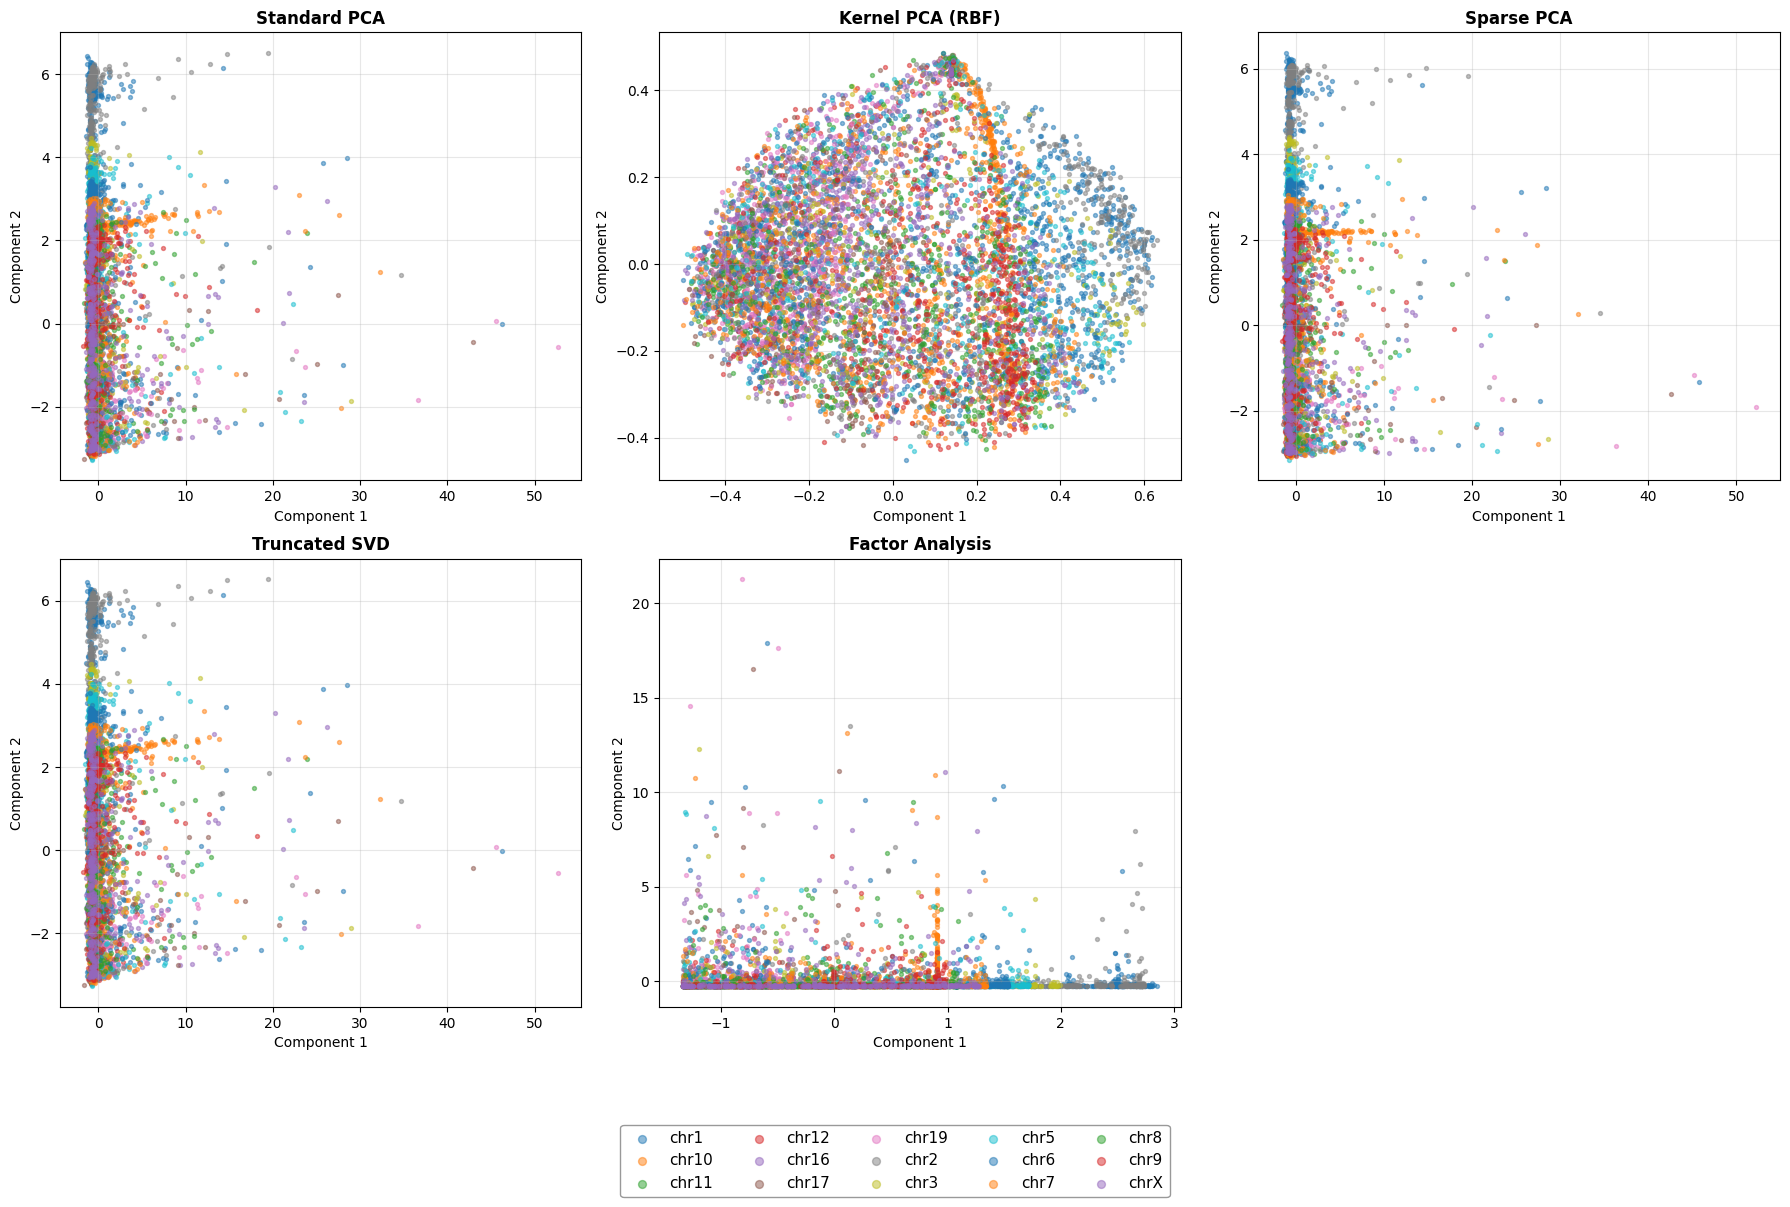

In [ ]:
# ============================================================
# 4. Figure 1: 2D scatter plots — all 5 decompositions
# ============================================================
projections_2d = {}
for name in decompositions:
    if name == 'Standard PCA':
        m = PCA(n_components=2)
    elif name == 'Kernel PCA (RBF)':
        m = KernelPCA(n_components=2, kernel='rbf', gamma=None, random_state=42)
    elif name == 'Sparse PCA':
        m = SparsePCA(n_components=2, alpha=1.0, ridge_alpha=0.01, max_iter=100, random_state=42, n_jobs=-1)
    elif name == 'Truncated SVD':
        m = TruncatedSVD(n_components=2, random_state=42)
    elif name == 'Factor Analysis':
        m = FactorAnalysis(n_components=2, random_state=42)
    projections_2d[name] = m.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for idx, (name, X2d) in enumerate(projections_2d.items()):
    ax = axes[idx]
    for ci, cname in enumerate(class_names):
        mask = y == ci
        ax.scatter(X2d[mask, 0], X2d[mask, 1], s=8, alpha=0.5, label=cname)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.3)

for j in range(len(projections_2d), len(axes)): axes[j].axis('off')
handles, lbls = axes[0].get_legend_handles_labels()
# Legend below the subplots, larger font, spread across 5 columns
fig.legend(handles, lbls, loc='upper center', ncol=5, fontsize=11,
           bbox_to_anchor=(0.5, -0.02), markerscale=2, frameon=True,
           edgecolor='gray', fancybox=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)  # make room for the legend below
plt.show()

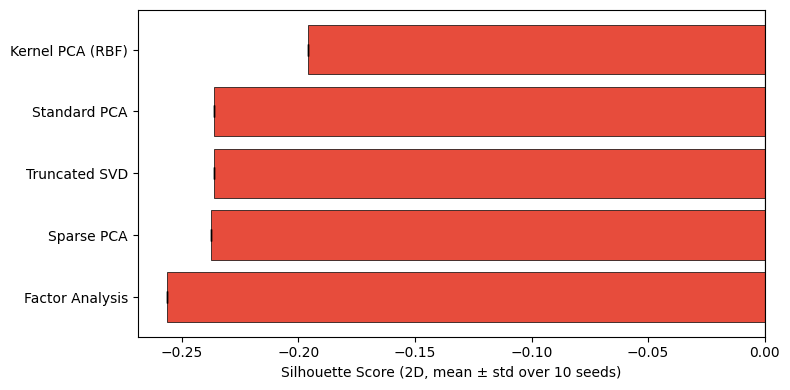

  Factor Analysis     : -0.2561 ± 0.0000
  Sparse PCA          : -0.2376 ± 0.0000
  Truncated SVD       : -0.2360 ± 0.0000
  Standard PCA        : -0.2360 ± 0.0000
  Kernel PCA (RBF)    : -0.1959 ± 0.0000


In [ ]:
# ============================================================
# 5. Figure 2: Silhouette scores WITH ERROR BARS
# ============================================================
sil_per_seed = {name: [] for name in decompositions}
for seed in SEEDS:
    for name in decompositions:
        if name == 'Standard PCA': m = PCA(n_components=2)
        elif name == 'Kernel PCA (RBF)': m = KernelPCA(n_components=2, kernel='rbf', gamma=None, random_state=42)
        elif name == 'Sparse PCA': m = SparsePCA(n_components=2, alpha=1.0, ridge_alpha=0.01, max_iter=50, random_state=42, n_jobs=-1)
        elif name == 'Truncated SVD': m = TruncatedSVD(n_components=2, random_state=42)
        elif name == 'Factor Analysis': m = FactorAnalysis(n_components=2, random_state=42)
        X2d = m.fit_transform(X_scaled)
        sil_per_seed[name].append(silhouette_score(X2d, y))

sil_means = [np.mean(sil_per_seed[n]) for n in decompositions]
sil_stds = [np.std(sil_per_seed[n]) for n in decompositions]
sil_names = list(decompositions.keys())
order = np.argsort(sil_means)

plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if sil_means[i] < 0 else '#2ecc71' for i in order]
plt.barh([sil_names[i] for i in order], [sil_means[i] for i in order],
         xerr=[sil_stds[i] for i in order], capsize=4, color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Silhouette Score (2D, mean \u00B1 std over 10 seeds)')
plt.tight_layout(); plt.show()

for i in order:
    print(f'  {sil_names[i]:20s}: {sil_means[i]:.4f} \u00B1 {sil_stds[i]:.4f}')

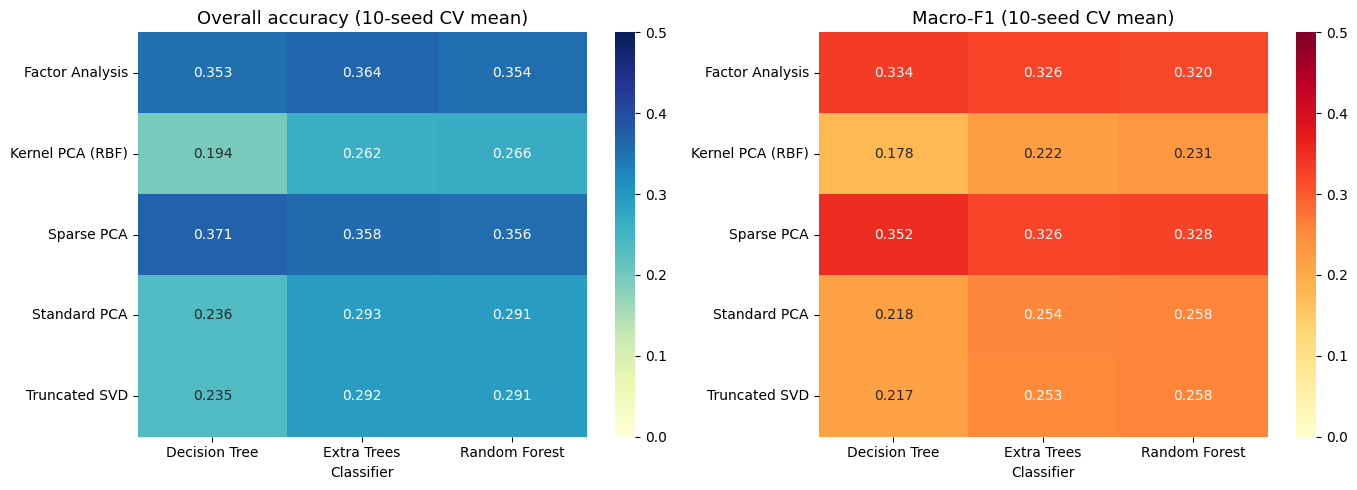

In [ ]:
# ============================================================
# 6. Figure 3: Heatmaps (Accuracy + Macro-F1 CV means)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, cmap, title in [
    (axes[0], 'Accuracy_mean', 'YlGnBu', 'Overall accuracy (10-seed CV mean)'),
    (axes[1], 'Macro-F1_mean', 'YlOrRd', 'Macro-F1 (10-seed CV mean)'),
]:
    pivot = df_summary.pivot(index='Decomposition', columns='Classifier', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax, vmin=0, vmax=0.5)
    ax.set_title(title, fontsize=13); ax.set_ylabel('')
plt.tight_layout(); plt.show()

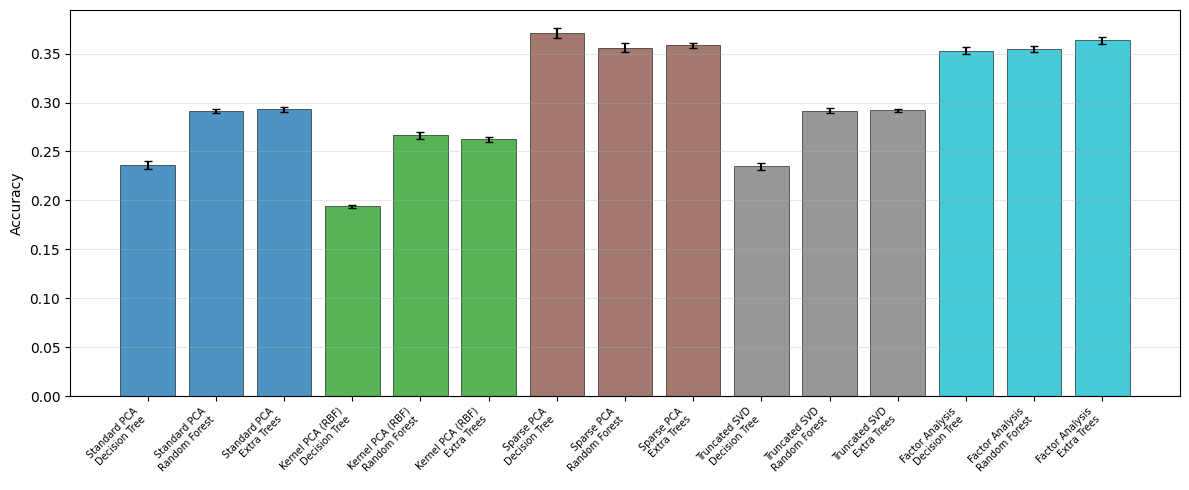

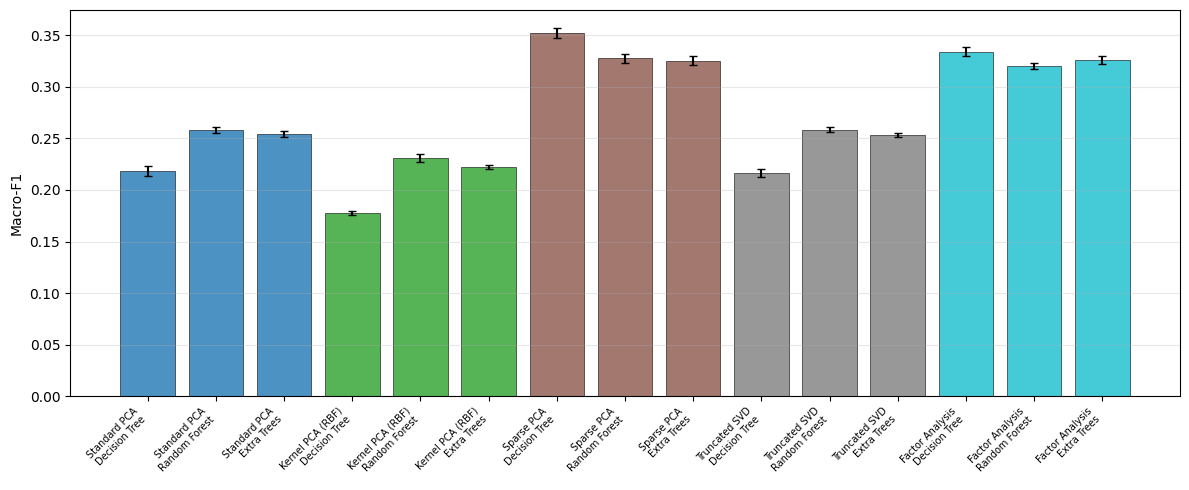

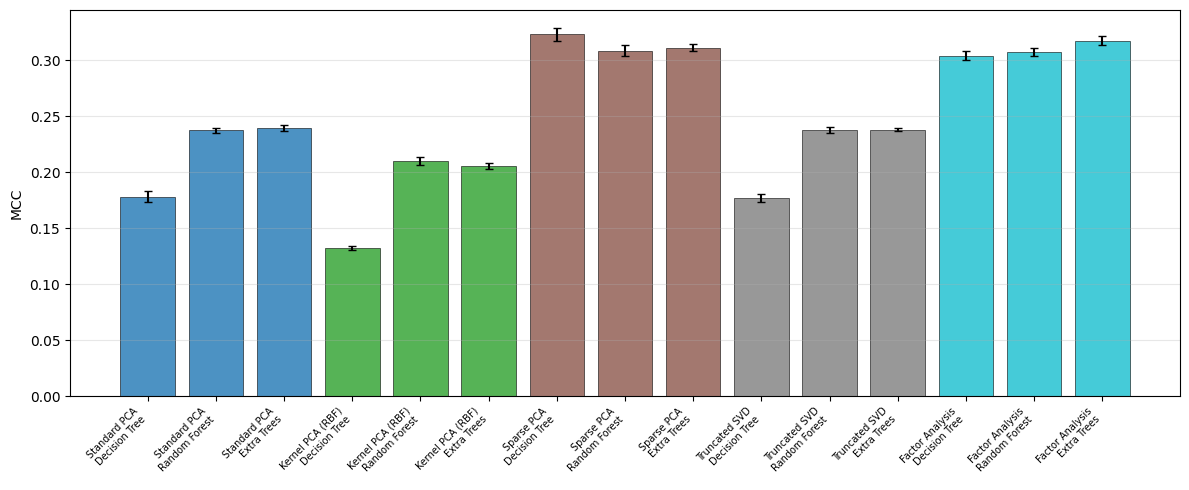

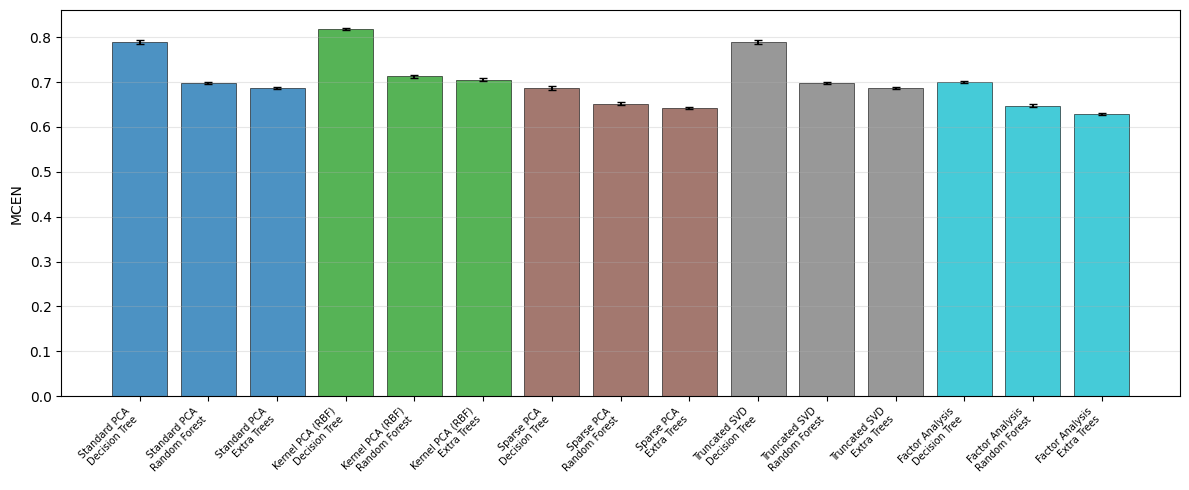

In [ ]:
# ============================================================
# 7. Figures 4-5: Bar charts WITH ERROR BARS (all 4 metrics)
# ============================================================
decomp_names = list(decompositions.keys())
clf_names = list(classifiers.keys())

for metric in ['Accuracy', 'Macro-F1', 'MCC', 'MCEN']:
    fig, ax = plt.subplots(figsize=(12, 5))
    x_labels, means, stds, colors = [], [], [], []
    cmap_c = plt.cm.get_cmap('tab10', len(decomp_names))

    for di, decomp_name in enumerate(decomp_names):
        for clf_name in clf_names:
            mask = (df_summary['Decomposition'] == decomp_name) & (df_summary['Classifier'] == clf_name)
            row = df_summary[mask].iloc[0]
            x_labels.append(f'{decomp_name}\n{clf_name}')
            means.append(row[f'{metric}_mean'])
            stds.append(row[f'{metric}_std'])
            colors.append(cmap_c(di))

    x = np.arange(len(x_labels))
    ax.bar(x, means, yerr=stds, capsize=3, color=colors, alpha=0.8,
           edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()

Best combo: Sparse PCA + Decision Tree
  Acc=0.3707±0.0051, F1=0.3522±0.0045, MCC=0.3228±0.0054

--- Classification Report ---
              precision    recall  f1-score   support

        chr1       0.39      0.36      0.38       170
       chr10       0.50      0.53      0.52       129
       chr11       0.23      0.22      0.22        92
       chr12       0.25      0.24      0.25        75
       chr16       0.60      0.58      0.59       134
       chr17       0.34      0.35      0.35        94
       chr19       0.30      0.33      0.32       102
        chr2       0.31      0.33      0.32       138
        chr3       0.24      0.27      0.25        79
        chr5       0.34      0.32      0.33       102
        chr6       0.29      0.26      0.27       112
        chr7       0.19      0.20      0.19        92
        chr8       0.27      0.24      0.25        67
        chr9       0.33      0.36      0.34        95
        chrX       0.24      0.25      0.24        92

    acc

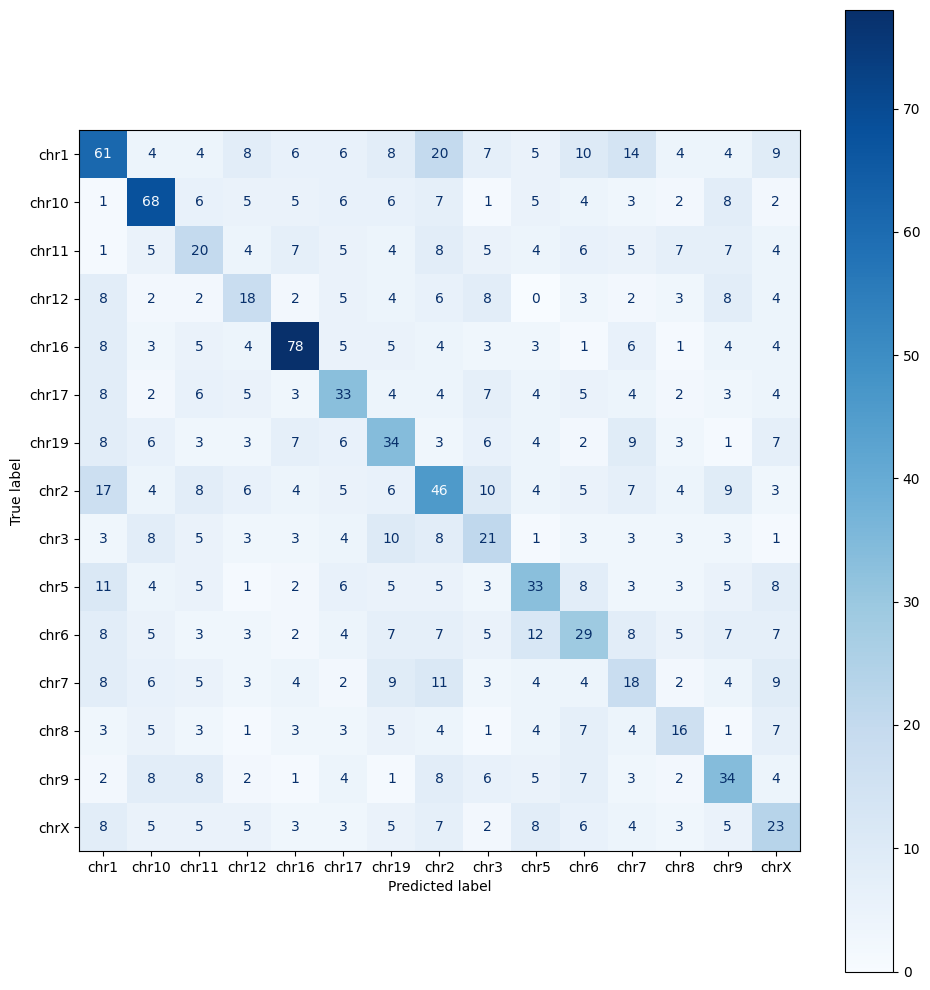

In [ ]:
# ============================================================
# 8. Figure 6: Best combo confusion matrix (fixed colorbar)
# ============================================================
best_idx = df_summary['Macro-F1_mean'].idxmax()
best_row = df_summary.loc[best_idx]
best_decomp = best_row['Decomposition']
best_clf = best_row['Classifier']
print(f'Best combo: {best_decomp} + {best_clf}')
print(f'  Acc={best_row["Accuracy_str"]}, F1={best_row["Macro-F1_str"]}, MCC={best_row["MCC_str"]}')

X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)
decomp = decompositions[best_decomp]()
X_tr_d = decomp.fit_transform(X_tr)
X_te_d = decomp.transform(X_te)
clf = classifiers[best_clf]()
clf.fit(X_tr_d, y_tr)
y_pred_best = clf.predict(X_te_d)

print('\n--- Classification Report ---')
print(classification_report(y_te, y_pred_best, target_names=class_names))

# PyCM
y_t_lbl = [str(class_names[i]) for i in y_te]
y_p_lbl = [str(class_names[i]) for i in y_pred_best]
cm_pycm = PyCM_CM(actual_vector=y_t_lbl, predict_vector=y_p_lbl)
ov = cm_pycm.overall_stat
mcen_best = compute_mcen(y_te, y_pred_best)
print(f'\nPyCM: MCC={ov.get("Overall MCC","N/A")}, MCEN(corrected)={mcen_best:.4f}, '
      f'CEN={ov.get("Overall CEN","N/A")}, Kappa={ov.get("Kappa","N/A")}')

cm_values = confusion_matrix(y_te, y_pred_best)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_best, display_labels=class_names, ax=ax, cmap='Blues',
    im_kw={'vmax': cm_values.max()}
)
plt.tight_layout(); plt.show()

==== RF on RAW features ====
Accuracy:  0.5410
Macro-F1:  0.5394
MCC=0.5114430368824926, MCEN(corrected)=0.5318, Kappa=0.5076729269658732


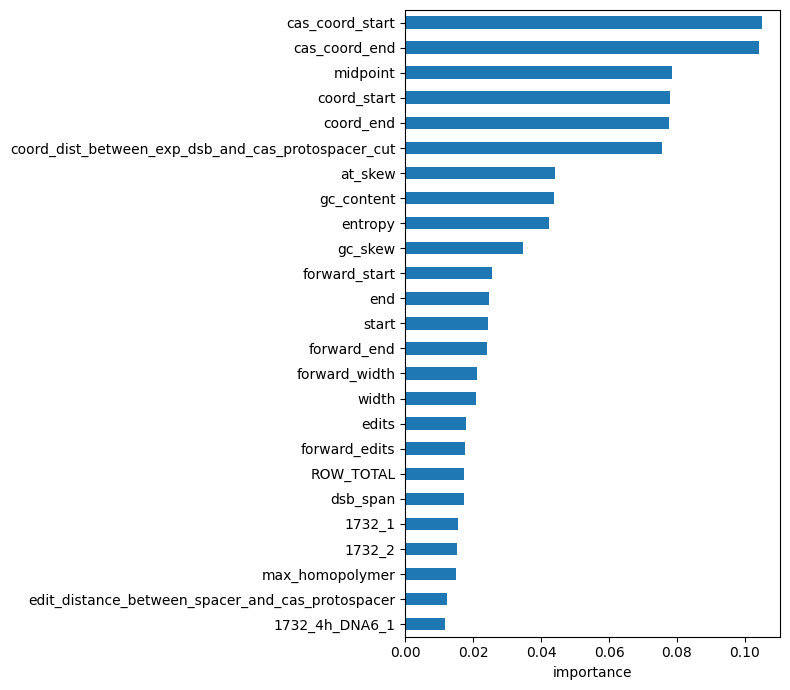

In [ ]:
# ============================================================
# 9. Figure 7: Raw features RF + importance
# ============================================================
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_raw, y, test_size=0.2, random_state=SEED, stratify=y)
rf_raw = RandomForestClassifier(n_estimators=800, max_depth=None, min_samples_leaf=3,
                                 class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_raw.fit(Xr_tr, yr_tr)
pred_raw = rf_raw.predict(Xr_te)

print(f'==== RF on RAW features ====')
print(f'Accuracy:  {accuracy_score(yr_te, pred_raw):.4f}')
print(f'Macro-F1:  {f1_score(yr_te, pred_raw, average="macro"):.4f}')
mcen_raw = compute_mcen(yr_te, pred_raw)
y_t_r = [str(class_names[i]) for i in yr_te]
y_p_r = [str(class_names[i]) for i in pred_raw]
cm_r = PyCM_CM(actual_vector=y_t_r, predict_vector=y_p_r)
ov_r = cm_r.overall_stat
print(f'MCC={ov_r.get("Overall MCC","N/A")}, MCEN(corrected)={mcen_raw:.4f}, Kappa={ov_r.get("Kappa","N/A")}')

importances = pd.Series(rf_raw.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 7))
importances.head(25).sort_values().plot(kind='barh')
plt.xlabel('importance')
plt.tight_layout(); plt.show()

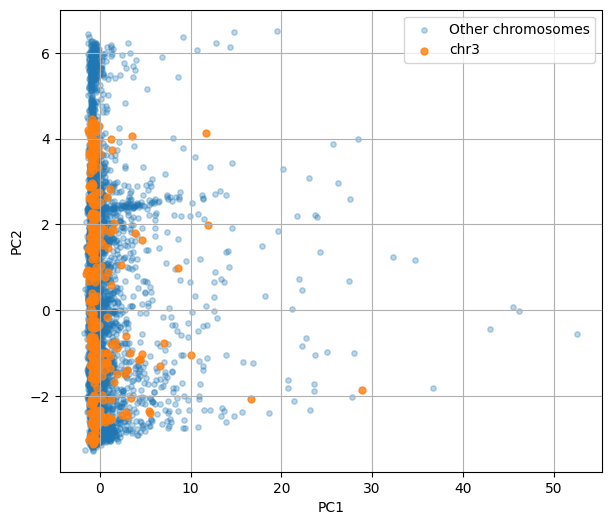

Centroid distance: 0.1376
chr3 spread: 2.4736, Other spread: 2.4322
Effect ratio: 0.0561

Binary chr3: Acc=0.9549, F1=0.6685, AUC=0.8791
MCC=0.37923927139030095, MCEN=0.1814, Kappa=0.3412858971258704


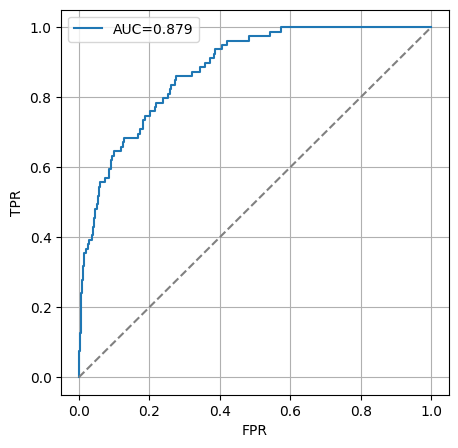

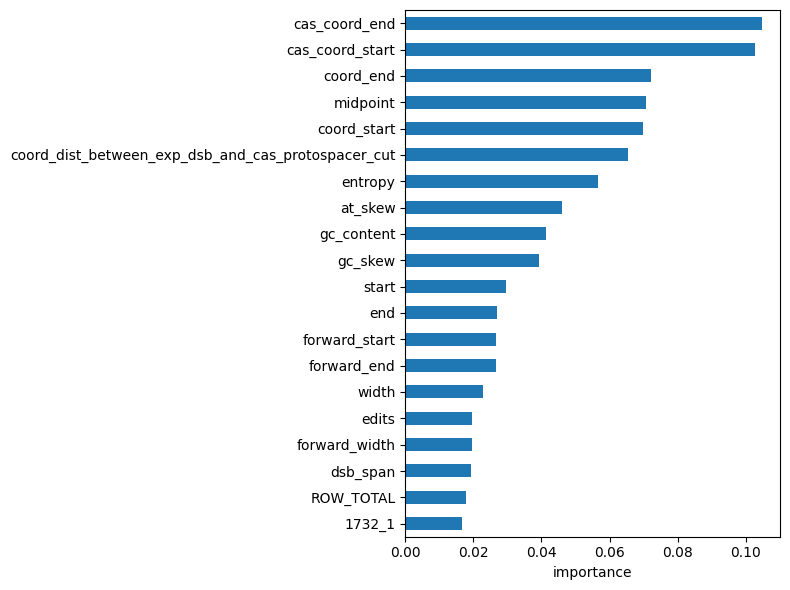

In [ ]:
# ============================================================
# 10. Figures 8-10: chr3 analysis (PCA scatter, ROC, importance)
# ============================================================
is_chr3 = labels_str == 'chr3'

# Figure 8: PCA scatter
X2_std = projections_2d['Standard PCA']
plt.figure(figsize=(7, 6))
plt.scatter(X2_std[~is_chr3, 0], X2_std[~is_chr3, 1], s=15, alpha=0.3, label='Other chromosomes')
plt.scatter(X2_std[is_chr3, 0], X2_std[is_chr3, 1], s=25, alpha=0.8, label='chr3')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True); plt.show()

chr3_center = X2_std[is_chr3].mean(axis=0)
other_center = X2_std[~is_chr3].mean(axis=0)
centroid_dist = np.linalg.norm(chr3_center - other_center)
chr3_spread = np.mean(np.linalg.norm(X2_std[is_chr3] - chr3_center, axis=1))
other_spread = np.mean(np.linalg.norm(X2_std[~is_chr3] - other_center, axis=1))
print(f'Centroid distance: {centroid_dist:.4f}')
print(f'chr3 spread: {chr3_spread:.4f}, Other spread: {other_spread:.4f}')
print(f'Effect ratio: {centroid_dist / ((chr3_spread + other_spread)/2):.4f}')

# Binary RF
y_chr3 = is_chr3.astype(int)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_raw, y_chr3, test_size=0.2, random_state=42, stratify=y_chr3)
rf_chr3 = RandomForestClassifier(n_estimators=800, min_samples_leaf=5, max_depth=None,
                                  class_weight='balanced', random_state=42, n_jobs=-1)
rf_chr3.fit(Xb_tr, yb_tr)
pred_prob = rf_chr3.predict_proba(Xb_te)[:, 1]
pred_bin = (pred_prob >= 0.5).astype(int)

print(f'\nBinary chr3: Acc={accuracy_score(yb_te, pred_bin):.4f}, '
      f'F1={f1_score(yb_te, pred_bin, average="macro"):.4f}, '
      f'AUC={roc_auc_score(yb_te, pred_prob):.4f}')
mcen_bin = compute_mcen(yb_te, pred_bin)
y_t_b = [str(x) for x in yb_te]; y_p_b = [str(x) for x in pred_bin]
cm_b = PyCM_CM(actual_vector=y_t_b, predict_vector=y_p_b)
ov_b = cm_b.overall_stat
print(f'MCC={ov_b.get("Overall MCC","N/A")}, MCEN={mcen_bin:.4f}, Kappa={ov_b.get("Kappa","N/A")}')

# Figure 9: ROC
fpr, tpr, _ = roc_curve(yb_te, pred_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(yb_te, pred_prob):.3f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.legend(); plt.grid(True); plt.show()

# Figure 10: Feature importance
imp_chr3 = pd.Series(rf_chr3.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp_chr3.head(20).sort_values().plot(kind='barh')
plt.xlabel('importance')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# 11. Figure 11: Timing with error bars
# ============================================================
skf_t = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
train_idx_0 = list(skf_t.split(X_scaled, y))[0][0]

timing_results = {name: [] for name in decompositions}
for rep in range(10):
    for name, fn in decompositions.items():
        decomp = fn()
        t0 = time()
        decomp.fit_transform(X_scaled[train_idx_0])
        timing_results[name].append(time() - t0)

t_means = [np.mean(timing_results[n]) for n in decompositions]
t_stds = [np.std(timing_results[n]) for n in decompositions]
t_names = list(decompositions.keys())
order = np.argsort(t_means)[::-1]

plt.figure(figsize=(8, 4))
plt.barh([t_names[i] for i in order], [t_means[i] for i in order],
         xerr=[t_stds[i] for i in order], capsize=4, color='steelblue',
         edgecolor='black', linewidth=0.5)
plt.xlabel('Time (seconds, mean \u00B1 std over 10 reps)')
plt.tight_layout(); plt.show()

for i in order:
    print(f'  {t_names[i]:20s}: {t_means[i]:.2f} \u00B1 {t_stds[i]:.2f}s')

In [ ]:
# ============================================================
# 12. Print full summary
# ============================================================
print('='*60)
print('COMPLETE EXPERIMENT SUMMARY')
print('='*60)
print(f'Dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features, {len(class_names)} classes')
print(f'Seeds: {N_SEEDS} (MD5-derived)')
print(f'Total experiments: {N_SEEDS * 10 * len(decompositions) * len(classifiers)}')
print(f'\nBest combo: {best_decomp} + {best_clf}')
print(f'  Accuracy: {best_row["Accuracy_str"]}')
print(f'  Macro-F1: {best_row["Macro-F1_str"]}')
print(f'  MCC:      {best_row["MCC_str"]}')
print(f'  MCEN:     {best_row["MCEN_str"]}')
print(f'\nFriedman: ALL significant')
for _, r in df_friedman.iterrows():
    print(f'  {r["Metric"]:10s} {r["Classifier"]:15s} \u03C7\u00B2({int(r["df"])})={r["chi2"]:.2f}, p={r["p"]:.2e} {r["sig"]}')
print(f'\nWilcoxon: {(df_posthoc["Sig"]!="ns").sum()}/{len(df_posthoc)} significant')
print(f'\nRaw features: Acc={accuracy_score(yr_te, pred_raw):.4f}, MCC={ov_r.get("Overall MCC","N/A")}')
print(f'Binary chr3: Acc={accuracy_score(yb_te, pred_bin):.4f}, AUC={roc_auc_score(yb_te, pred_prob):.4f}')

In [ ]:
# ============================================================
# Effect sizes: Kendall's W (Friedman), Wilcoxon r, Shapiro-Wilk
# ============================================================
from scipy.stats import friedmanchisquare, wilcoxon, shapiro, rankdata
from itertools import combinations

# Already loaded: df_all, decomp_names, clf_names

def kendall_w(arrays):
    """Kendall's W effect size for Friedman ANOVA."""
    n = len(arrays[0])  # number of subjects (repetitions)
    k = len(arrays)      # number of groups (decompositions)
    # Rank within each subject
    data = np.column_stack(arrays)
    ranks = np.apply_along_axis(rankdata, 1, data)
    rank_sums = ranks.sum(axis=0)
    mean_rank = np.mean(rank_sums)
    SS = np.sum((rank_sums - mean_rank)**2)
    W = (12 * SS) / (n**2 * (k**3 - k))
    return W

print('=== EFFECT SIZES ===\n')
print('--- Kendall\'s W (Friedman ANOVA effect size) ---')
print('Interpretation: .1=small, .3=moderate, .5=large\n')

for metric in ['Accuracy', 'Macro-F1', 'MCC']:
    for c_name in clf_names:
        arrays = []
        for d_name in decomp_names:
            mask = (df_all['Decomposition'] == d_name) & (df_all['Classifier'] == c_name)
            vals = df_all[mask].sort_values('Seed_idx')[metric].values
            arrays.append(vals)
        W = kendall_w(arrays)
        stat, p = friedmanchisquare(*arrays)
        print(f'  {metric:10s} {c_name:15s}: W = {W:.3f}, χ²(4) = {stat:.2f}, p = {p:.2e}')
    print()

print('\n--- Wilcoxon r (pairwise effect size) ---')
print('r = Z / sqrt(N), Interpretation: .1=small, .3=moderate, .5=large\n')

wilcoxon_r_results = []
for metric in ['Accuracy', 'Macro-F1', 'MCC']:
    for c_name in clf_names:
        pairs = list(combinations(range(len(decomp_names)), 2))
        for i, j in pairs:
            mask_i = (df_all['Decomposition'] == decomp_names[i]) & (df_all['Classifier'] == c_name)
            mask_j = (df_all['Decomposition'] == decomp_names[j]) & (df_all['Classifier'] == c_name)
            vals_i = df_all[mask_i].sort_values('Seed_idx')[metric].values
            vals_j = df_all[mask_j].sort_values('Seed_idx')[metric].values
            try:
                stat, p = wilcoxon(vals_i, vals_j)
                # Z approximation from Wilcoxon
                n = len(vals_i)
                # Use normal approximation: Z = (T - mean) / std
                diff = vals_i - vals_j
                ranks_abs = rankdata(np.abs(diff))
                T_plus = np.sum(ranks_abs[diff > 0])
                T_minus = np.sum(ranks_abs[diff < 0])
                T = min(T_plus, T_minus)
                mean_T = n * (n + 1) / 4
                std_T = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
                Z = (T - mean_T) / std_T if std_T > 0 else 0
                r = abs(Z) / np.sqrt(n)
            except:
                r = 0; p = 1.0
            wilcoxon_r_results.append({
                'Metric': metric, 'Classifier': c_name,
                'Pair': f'{decomp_names[i]} vs {decomp_names[j]}',
                'r': r, 'p': p
            })

df_r = pd.DataFrame(wilcoxon_r_results)
# Show for Accuracy
print('Accuracy effect sizes:')
acc_r = df_r[df_r['Metric'] == 'Accuracy'][['Classifier','Pair','r','p']].round(3)
display(acc_r)

print('\n--- Shapiro-Wilk normality test on pairwise differences ---')
for c_name in clf_names:
    print(f'\n  {c_name}:')
    for i, j in list(combinations(range(len(decomp_names)), 2))[:5]:
        mask_i = (df_all['Decomposition'] == decomp_names[i]) & (df_all['Classifier'] == c_name)
        mask_j = (df_all['Decomposition'] == decomp_names[j]) & (df_all['Classifier'] == c_name)
        vals_i = df_all[mask_i].sort_values('Seed_idx')['Accuracy'].values
        vals_j = df_all[mask_j].sort_values('Seed_idx')['Accuracy'].values
        diff = vals_i - vals_j
        stat, p = shapiro(diff)
        normal = 'normal' if p > .05 else 'NOT normal'
        print(f'    {decomp_names[i]:20s} vs {decomp_names[j]:20s}: W={stat:.3f}, p={p:.3f} ({normal})')

# Save
df_r.to_csv(os.path.join(RESULTS_DIR, 'effect_sizes.csv'), index=False)
print('\nEffect sizes saved to effect_sizes.csv')